In [20]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.image import imread
import requests
from io import BytesIO
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
from PIL import Image
from neo4j import GraphDatabase
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv 
load_dotenv(dotenv_path = os.path.join(os.getcwd(),'config/.env'))
import os
import ipywidgets as widgets
from IPython.display import display

In [21]:
NEO4J_URI='neo4j+ssc://c1a2ef8c.databases.neo4j.io'
NEO4J_USERNAME='neo4j'
NEO4J_PASSWORD='Lwei5lLD2F5v5dOUwrpZCbrY7TZ5IRq_weyj9_AjGqQ'
AURA_INSTANCEID='c1a2ef8c'
AURA_INSTANCENAME='Instance01'


In [22]:

USER=os.getenv("NEO4J_USERNAME")
URI="neo4j+ssc://c1a2ef8c.databases.neo4j.io"
PASSWORD = 'Lwei5lLD2F5v5dOUwrpZCbrY7TZ5IRq_weyj9_AjGqQ'
driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

In [23]:
def visualise_best_team(defenders, midfielders, forwards,season):
    ## creating pitch with mplsoccer
    pitch = VerticalPitch(line_color='white', pitch_color='green' )
    fig, ax = pitch.draw(figsize=(16, 8))
    fig.patch.set_facecolor('green')
    def add_image_to_plot(ax, url, x, y):
        ## getting image from link
        response = requests.get(url, timeout=5)
        img_data = BytesIO(response.content)
        img = Image.open(img_data)
        imagebox = OffsetImage(img, zoom=0.3)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
        
        

    # Plot defenders
    for i, defender in enumerate(defenders):
        if i in {3,1}:
            ax.text( 15+ i * 20, 25, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        else:
            ax.text( 10+ i * 23, 22.5, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        
        x, y =  10+i * 22.5, 35
        add_image_to_plot(ax, defender['player']['img'], x, y)
        stat = defender["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')

    # Plot midfieldersx
    for i, midfielder in enumerate(midfielders):
        ax.text(i*35, 50 , f"{midfielder['player']['name']} ", fontsize=12, color='white')
        x, y = i * 35+5, 60
        add_image_to_plot(ax, midfielder['player']['img'], x, y)
        stat = midfielder["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')


    # Plot forwards
    for i, forward in enumerate(forwards):
        ax.text(i*35, 80, f"{forward['player']['name']} ", fontsize=12, color='white')
        x, y =  i * 35+5, 90
        add_image_to_plot(ax, forward['player']['img'], x, y)
        stat = forward["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')
    title = season+': Best Starting XI Visualization'
    plt.title(title)
    plt.show()

In [24]:
## method to find highest average stat of player over all seasons played
def find_highest_stat_oat(stat):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)
    
    WHERE stats.{stat} IS NOT NULL 
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

In [25]:
## method to retrieve player with highest stat during particular season
def find_highest_stat(stat,season):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]->(s)
    
    WHERE stats.{stat} IS NOT NULL AND s.season = "{season}"
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

plot for top team by stats

In [26]:
def visualise_team(defenders, midfielders, forwards,query_stat):
    ## creating pitch using mplsoccer
    pitch = VerticalPitch(line_color='white', pitch_color='green' )
    fig, ax = pitch.draw(figsize=(16, 8))
    fig.patch.set_facecolor('green')
    def add_image_to_plot(ax, url, x, y):
         ## getting image from link
        response = requests.get(url, timeout=5)
        img_data = BytesIO(response.content)
        img = Image.open(img_data)
        imagebox = OffsetImage(img, zoom=0.3)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
            
    # Plot defenders
    for i, defender in enumerate(defenders):
        if i in {3,1}:
            ax.text( 15+ i * 20, 25, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        else:
            ax.text( 10+ i * 23, 22.5, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        
        x, y =  10+i * 22.5, 35
        add_image_to_plot(ax, defender['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{defender['avg_stat']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        

    # Plot midfieldersx
    for i, midfielder in enumerate(midfielders):
        ax.text(i*35, 50 , f"{midfielder['player']['name']} ", fontsize=12, color='white')
        x, y = i * 35+5, 60
        add_image_to_plot(ax, midfielder['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{midfielder['avg_stat']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        


    # Plot forwards
    for i, forward in enumerate(forwards):
        ax.text(i*35, 80, f"{forward['player']['name']} ", fontsize=12, color='white')
        x, y =  i * 35+5, 90
        add_image_to_plot(ax, forward['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{forward['avg_stat']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        
    title = 'Starting XI Greatest: '+ str(query_stat)
    plt.title(title)
    plt.show()

In [27]:
## method retrieves a starting xi (minus a goal keeper) of players in correct positions with the highest chosen stat
def get_top_team_by_stat(season, query_stat):
    query= f"""
        // find defenders that played for squad in season
    MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(def.position) CONTAINS "B" AND squad.season = "{season}"
    AND def.img IS NOT NULL

        // retreive stats from match played during season
    MATCH (def)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    WITH def, AVG(stats.{query_stat}) AS avg_stat, def.img as img

        // Sorting so players with highest stat at top of result
    ORDER BY avg_stat DESC
    LIMIT 4

         // Players image and stat collected and names collected in excluded players list to ensure players with multiple positions do not repeat
    WITH COLLECT(DISTINCT{{player: def, avg_stat: avg_stat, img: img}}) AS defenders,COLLECT(def.name) AS excluded_players

           // find forwards that played for squad in season
    MATCH (fw:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(fw.position) CONTAINS "W" AND squad.season = "{season}"

            // Checking player is not already in squad
    AND fw.img IS NOT NULL AND NOT fw.name IN excluded_players
    MATCH (fw)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    WITH defenders, fw, AVG(stats.{query_stat}) AS avg_stat, fw.img as img
    ORDER BY avg_stat DESC
    LIMIT 3

    WITH defenders, COLLECT(DISTINCT{{player: fw, avg_stat: avg_stat, img: img}}) AS forwards,COLLECT(fw.name) AS excluded_players

           // find midfielders that played for squad in season
    MATCH (mid:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(mid.position) CONTAINS "M" AND squad.season = "{season}" 
    AND mid.img IS NOT NULL AND NOT mid.name IN excluded_players
    MATCH (mid)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    WITH defenders,mid,forwards, AVG(stats.{query_stat}) AS avg_stat, mid.img as img
    ORDER BY avg_stat DESC
    LIMIT 3

    WITH defenders,forwards, COLLECT(DISTINCT{{player: mid, avg_stat: avg_stat, img: img}}) AS midfielders

    return defenders,midfielders,forwards
    """
    with driver.session() as session:
        result = session.run(query)
        for record in result:
                defenders = record['defenders']
                midfielders = record['midfielders']
                forwards = record['forwards']
                
                visualise_team(defenders, midfielders, forwards,query_stat)
    driver.close()

In [28]:
## Dropdown boxes for selections
stat_options = [
    "goals", "assists", "penalties", "shots", "shots_on_target", "touches",
    "tackles", "interceptions", "blocks", "xg", "npxg", "xag", "sca", "gca",
    "passes_completed", "passes_attempted", "progressive_passes", "carries"
]
stat_dropdown = widgets.Dropdown(
    options=stat_options,
    value="goals",
    description="Stat:",
    style={'description_width': 'initial'}
)
season_dropdown = widgets.Dropdown(
    options=["2021-2022", "2022-2023", "2023-2024", "2024-2025"],  
    value="2024-2025",
    description="Season:",
    style={'description_width': 'initial'}
)
widgets.interactive(get_top_team_by_stat, query_stat=stat_dropdown, season=season_dropdown)

interactive(children=(Dropdown(description='Season:', index=3, options=('2021-2022', '2022-2023', '2023-2024',…

In [39]:
def get_best_team(season):
   ## Here the max of every stat used to calculate player scores is calculated for later in normalisation process
    max_blocks=find_highest_stat("blocks",season)
    max_shots=find_highest_stat("shots",season)
    max_interceptions=find_highest_stat("interceptions",season)
    max_tackles=find_highest_stat("tackles",season)
    max_goals=find_highest_stat("goals",season)
    max_assists=find_highest_stat("assists",season)
    max_xg = find_highest_stat("xg",season)
    max_carries = find_highest_stat("progressive_carries",season)
    max_pass = find_highest_stat("progressive_passes",season)

    query= f"""
         // Matching defenders that played in squads during specific year and retrieving their stats while playing in position
    
    MATCH (def)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(stats.position) CONTAINS "B" AND squad.season = "{season}"
    AND def.img IS NOT NULL

        // averages for every stat calculated
    WITH def,
        AVG(stats.blocks) AS avg_blocks,
        AVG(stats.interceptions) AS avg_interceptions,
        AVG(stats.tackles) AS avg_tackles,
        AVG(stats.goals) AS avg_goals,
        AVG(stats.assists) AS avg_assists,
        AVG(stats.xg) as avg_xg,
        AVG(stats.progressive_carries) as avg_carries,
        AVG(stats.progressive_passes) as avg_pass,
        def.img as img

            // averages normalised by max stats retrieved earlier to ensure stats that are typically lower (e.g progressive passes > goals) are accounted for
            // Weights are also applied so that scores are reflective of positions
    WITH def, img,
        0.2 * (avg_blocks / {max_blocks}) +
        0.2 * (avg_interceptions / {max_interceptions}) +
        0.2 * (avg_tackles  / {max_tackles} ) +
        0.05 * (avg_goals / {max_goals})+
        0.05 * (avg_assists/ {max_assists})+
        0.05 *(avg_xg/{max_xg})+
        0.05*(avg_carries/{max_carries})+
        0.2*(avg_pass/{max_pass})
    AS raw_performance_score

            // Highest scores at the top
    ORDER BY raw_performance_score DESC

            //Players stored in order, excluded_players populated to avoid repeating players (multiple positions)
    WITH COLLECT(DISTINCT{{player: def, performance: raw_performance_score, img: img}}) AS defenders,COLLECT(def.name) AS excluded_players,

             // Min and max scores for position calculated for later normalisation
        MIN(raw_performance_score) AS min_def_score, 
        MAX(raw_performance_score) AS max_def_score

        

        // Matching forwards that played in squads during specific year and retrieving their stats
    

             // Ensure player has no already been selected
    
    MATCH (fw)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"AND NOT fw.name IN excluded_players
    MATCH (fw:Player)-[:IS_IN_SQUAD]->(squad:Squad)     
    WHERE TOUPPER(stats.position) CONTAINS "W" AND squad.season = "{season}"
    


        // averages for every stat calculated
    WITH fw, defenders,min_def_score, max_def_score,
        AVG(stats.goals) AS avg_goals,
        AVG(stats.assists) AS avg_assists,
        AVG(stats.xg) as avg_xg,
        AVG(stats.progressive_carries) as avg_carries,
        AVG(stats.progressive_passes) as avg_pass,
        AVG(stats.shots) as avg_shots

            // averages normalised by max stats retrieved earlier to ensure stats that are typically lower (e.g progressive passes > goals) are accounted for
            // Weights are also applied so that scores are reflective of positions  
    WITH defenders,fw,min_def_score, max_def_score,
        0.15*(avg_shots/{max_shots})+
        0.5 * (avg_goals / {max_goals})+
        0.1 * (avg_assists/ {max_assists})+
        0.175 *(avg_xg/{max_xg})+
        0.05*(avg_carries/{max_carries})+
        0.025*(avg_pass/{max_pass}) as raw_performance_score,
        fw.img AS img
    ORDER BY raw_performance_score DESC

    WITH defenders,min_def_score, max_def_score, COLLECT({{player: fw, performance:raw_performance_score, img: img}}) AS forwards,COLLECT(fw.name) AS excluded_players,

            // For later normalisation
        MIN(raw_performance_score) AS min_fw_score, 
        MAX(raw_performance_score) AS max_fw_score

        


         // Matching midfeilders that played in squads during specific year and retrieving their stats
    MATCH (mid)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}" AND NOT mid.name IN excluded_players
    MATCH (mid:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(stats.position) CONTAINS "M" AND squad.season = "{season}" 
   
    
        // averages for every stat calculated
    with defenders, mid,forwards, min_def_score, max_def_score, min_fw_score, max_fw_score,
        AVG(stats.interceptions) AS avg_interceptions,
        AVG(stats.tackles) AS avg_tackles,
        AVG(stats.goals) AS avg_goals,
        AVG(stats.assists) AS avg_assists,
        AVG(stats.xg) as avg_xg,
        AVG(stats.progressive_carries) as avg_carries,
        AVG(stats.progressive_passes) as avg_pass,
        AVG(stats.shots) as avg_shots,
        mid.img as img

        // averages normalised by max stats retrieved earlier to ensure stats that are typically lower (e.g progressive passes > goals) are accounted for
        // Weights are also applied so that scores are reflective of positions
    with defenders, mid, img,forwards, min_def_score, max_def_score, min_fw_score, max_fw_score,
        0.1*(avg_shots/{max_shots})+
        0.1 * (avg_interceptions / {max_interceptions}) +
        0.1 * (avg_tackles  / {max_tackles} ) +
        0.3 * (avg_goals / {max_goals})+
        0.1 * (avg_assists/ {max_assists})+
        0.1 *(avg_xg/{max_xg})+
        0.1*(avg_carries/{max_carries})+
        0.1*(avg_pass/{max_pass}) as raw_performance_score

    ORDER BY raw_performance_score DESC


    WITH defenders,forwards,min_def_score, max_def_score, min_fw_score, max_fw_score,  COLLECT({{player: mid, performance: raw_performance_score, img: img}}) AS midfielders,
    MIN(raw_performance_score) AS min_mid_score,
        MAX(raw_performance_score) AS max_mid_score

        // Final normalisation to give score out of ten

    WITH defenders, forwards, midfielders,
        min_def_score, max_def_score, 
        min_fw_score, max_fw_score, 
        min_mid_score, max_mid_score

        
        // Below gives worst player score of 0, and best player a 10
        // Limits are applied to return a 4-3-3 formation

        // defender normalisation
    UNWIND defenders AS def
    WITH def, (def.performance - min_def_score) / (max_def_score - min_def_score) * 10 AS normalised_score,
        forwards, midfielders,
        min_fw_score, max_fw_score, 
        min_mid_score, max_mid_score
    LIMIT 4

        // forward normalisation
    WITH COLLECT({{player: def.player, performance: def.performance, img: def.img, normalised_score: normalised_score}}) AS defenders,
        forwards, midfielders,
        min_fw_score, max_fw_score, 
        min_mid_score, max_mid_score


    UNWIND forwards AS fw
    WITH fw, (fw.performance - min_fw_score) / (max_fw_score - min_fw_score) * 10 AS normalised_score,
        defenders, midfielders,
        min_mid_score, max_mid_score
    LIMIT 3

        //midfielder normalisation
    WITH defenders, COLLECT({{player: fw.player, performance: fw.performance, img: fw.img, normalised_score: normalised_score}}) AS forwards,
        midfielders, min_mid_score, max_mid_score
    UNWIND midfielders AS mid
    WITH mid, (mid.performance - min_mid_score) / (max_mid_score - min_mid_score) * 10 AS normalised_score,
        defenders, forwards
    LIMIT 3
    WITH defenders, forwards, COLLECT({{player: mid.player, performance: mid.performance, img: mid.img, normalised_score: normalised_score}}) AS midfielders

    return defenders,midfielders,forwards
    """

    with driver.session() as session:
        result = session.run(query)
        for record in result:
                defenders = record['defenders']
                midfielders = record['midfielders']
                forwards = record['forwards']
                visualise_best_team(defenders, midfielders, forwards,season)
    driver.close()


In [40]:
season_dropdown2 = widgets.Dropdown(
    options=["2021-2022", "2022-2023", "2023-2024", "2024-2025"],  
    value="2024-2025",
    description="Season:",
    style={'description_width': 'initial'}
)
widgets.interactive(get_best_team, season=season_dropdown2)


interactive(children=(Dropdown(description='Season:', index=3, options=('2021-2022', '2022-2023', '2023-2024',…

# Finding Defender with highest growth between any two seasons

In [45]:
import pandas as pd
max_blocks=find_highest_stat_oat("blocks")
max_shots=find_highest_stat_oat("shots")
max_interceptions=find_highest_stat_oat("interceptions")
max_tackles=find_highest_stat_oat("tackles")
max_goals=find_highest_stat_oat("goals")
max_assists=find_highest_stat_oat("assists")
max_xg = find_highest_stat_oat("xg")
max_carries = find_highest_stat_oat("progressive_carries")
max_pass = find_highest_stat_oat("progressive_passes")
query=f"""
WITH ["2021-2022", "2022-2023", "2023-2024", "2024-2025"] AS seasons

// Loops through every two season stopping at "2023-2024", "2024-2025"
// The logic for looping through seasons was created with aid from ChatGPT
UNWIND RANGE(0, SIZE(seasons) - 2) AS season_id
WITH seasons[season_id] AS season1, seasons[season_id + 1] AS season2

MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
WHERE TOUPPER(def.position) CONTAINS "B"

// Retrieving stats from previous and current season
MATCH (def)-[stats1:PLAYS_IN]->(m1:Match)-[:IS_PART_OF]->(s1)
WHERE s1.season = season1


MATCH (def)-[stats2:PLAYS_IN]-(m2:Match)-[:IS_PART_OF]-(s2)
WHERE s2.season = season2

// Calculating averages of all stats
WITH def, season1, season2,
AVG(stats1.blocks) AS avg_blocks1,
AVG(stats1.interceptions) AS avg_interceptions1,
AVG(stats1.tackles) AS avg_tackles1,
AVG(stats1.goals) AS avg_goals1,
AVG(stats1.assists) AS avg_assists1,
AVG(stats1.xg) as avg_xg1,
AVG(stats1.progressive_carries) as avg_carries1,
AVG(stats1.progressive_passes) as avg_pass1,
AVG(stats2.blocks) AS avg_blocks2,
AVG(stats2.interceptions) AS avg_interceptions2,
AVG(stats2.tackles) AS avg_tackles2,
AVG(stats2.goals) AS avg_goals2,
AVG(stats2.assists) AS avg_assists2,
AVG(stats2.xg) as avg_xg2,
AVG(stats2.progressive_carries) as avg_carries2,
AVG(stats2.progressive_passes) as avg_pass2

// Applying weighting for each stat, 
// This time using the best average stats of all time to weight in order to ensure comparibility
WITH def, season1, season2,
0.2 * (avg_blocks1 / {max_blocks}) +
0.2 * (avg_interceptions1 / {max_interceptions}) +
0.2 * (avg_tackles1  / {max_tackles}) +
0.05 * (avg_goals1 / {max_goals})+
0.05 * (avg_assists1/ {max_assists})+
0.05 *(avg_xg1/{max_xg})+
0.05*(avg_carries1/{max_carries})+
0.3*(avg_pass1/30) AS score_1,
0.2 * (avg_blocks2 /  {max_blocks}) +
0.2 * (avg_interceptions2 /  {max_interceptions}) +
0.2 * (avg_tackles2  / {max_tackles} ) +
0.05 * (avg_goals2 / {max_goals})+
0.05 * (avg_assists2/ {max_assists})+
0.05 *(avg_xg2/{max_xg})+
0.05*(avg_carries2/{max_carries})+
0.3*(avg_pass2/30) AS score_2

// Remove players with score_1 = 0 to avoid division by zero
WHERE score_1 > 0

WITH def, season1, season2, score_1, score_2, (score_2 - score_1)/score_1*100 AS growth

ORDER BY growth DESC

WITH def, season1, season2, score_1, score_2, growth
LIMIT 10

RETURN def.name AS player, season1, season2, score_1, score_2, growth
"""
growth_data = []
with driver.session() as session:
    result = session.run(query)
    for record in result:
            growth_data.append({"Player":record["player"],"Growth (%)":record["growth"],"Seasons":record["season1"]+"-->"+record["season2"]})
driver.close()
growth_df = pd.DataFrame(growth_data)


/var/folders/rr/8gfsct5527d2w34_mknbmycm0000gn/T/ipykernel_90490/2093205731.py:13: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
/var/folders/rr/8gfsct5527d2w34_mknbmycm0000gn/T/ipykernel_90490/1922154011.py:82: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


In [46]:
growth_df

,Player,Growth (%),Seasons
0,Neco Williams,553.936818,2021-2022-->2022-2023
1,Tyrone Mings,323.102215,2023-2024-->2024-2025
2,Jamaal Lascelles,299.252562,2022-2023-->2023-2024
3,Matt Ritchie,243.040248,2022-2023-->2023-2024
4,Cody Drameh,143.478261,2021-2022-->2022-2023
5,Valentino Livramento,117.450442,2022-2023-->2023-2024
6,Ainsley Maitland-Niles,112.604352,2021-2022-->2022-2023
7,Jaïro Riedewald,111.791747,2022-2023-->2023-2024
8,Matt Doherty,101.780616,2023-2024-->2024-2025
9,Lisandro Martínez,98.736020,2023-2024-->2024-2025


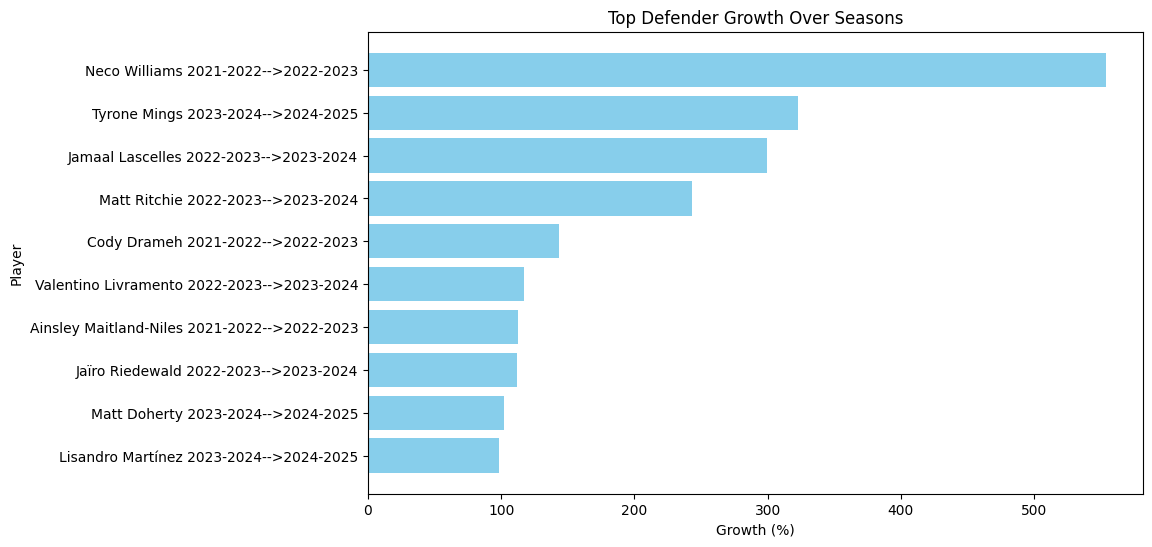

In [47]:

growth_df_sorted = growth_df.sort_values(by="Growth (%)", ascending=False)
plt.figure(figsize=(10, 6))
plt.barh((growth_df_sorted["Player"]+" "+growth_df_sorted["Seasons"]), growth_df_sorted["Growth (%)"], color='skyblue')
plt.xlabel("Growth (%)")
plt.ylabel("Player")
plt.title("Top Defender Growth Over Seasons")
plt.gca().invert_yaxis() 
plt.show()